# 05 — Diffusion-Based Innovation Learning

## Purpose
This notebook trains diffusion models on forecast residuals and evaluates their ability to recover complex innovation distributions.

## Outputs
- Trained diffusion innovation models
- Generated innovation samples
- Distribution recovery diagnostics
- Moment and quantile recovery analysis

## Future Work
- Tune diffusion architecture and training schedule
- Investigate conditional and calibration-aware diffusion models

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent
sys.path.append(str(ROOT))

import numpy as np
import pandas as pd

from src.utils.seeds import set_seed
from src.utils.device import get_device

from src.experiments.config import ExperimentConfig
from src.experiments.paths import result_dirs
from src.experiments.artifacts import (
    load_array_npz,
    save_array_npz,
    save_table,
    save_json,
    save_current_figure,
)

from src.api.innovations import (
    fit_innovations,
    sample_innovations,
)

set_seed(123)

config = ExperimentConfig()
device = get_device()

dirs = result_dirs(
    "05_diffusion",
    test=False,
)

device

device(type='mps')

In [2]:
forecast_models = [
    "VAR",
    "RNN",
]

dgp_names = config.dgp_names

diffusion_kwargs = {
    "timesteps": 200,
    "beta_start": 1e-4,
    "beta_end": 2e-2,
    "batch_size": 64,
    "epochs": 1500,
    "lr": 5e-4,
    "hidden_dim": 256,
    "time_embedding_dim": 64,
    "n_samples": 10_000,
    "device": device,
}

resid_dir = ROOT / "results" / "residuals" / "03_residuals"

residual_store = {}

for forecast_model in forecast_models:

    residual_store[forecast_model] = {}

    model_key = forecast_model.lower()

    for name in dgp_names:
        path = resid_dir / f"{name}_{model_key}_residuals.npz"
        data = load_array_npz(path)

        residuals = data["residuals"]

        residual_store[forecast_model][name] = residuals

        print(
            forecast_model,
            name,
            residuals.shape,
        )

VAR gaussian (299, 3)
VAR student_t (299, 3)
VAR mixture (299, 3)
VAR heteroskedastic (299, 3)
RNN gaussian (260, 3)
RNN student_t (260, 3)
RNN mixture (260, 3)
RNN heteroskedastic (260, 3)


In [3]:
from src.api.innovations import (
    fit_and_sample_diffusion_innovations,
)
diffusion_models, diffusion_samples = fit_and_sample_diffusion_innovations(
    residual_store=residual_store,
    forecast_models=forecast_models,
    dgp_names=dgp_names,
    output_dir=dirs["innovations"],
    seed=config.seed,
    **diffusion_kwargs,
)


Training diffusion model: VAR | gaussian
Epoch 0001 | loss = 0.921669
Epoch 0025 | loss = 0.616193
Epoch 0050 | loss = 0.597984
Epoch 0075 | loss = 0.585208
Epoch 0100 | loss = 0.549874
Epoch 0125 | loss = 0.546590
Epoch 0150 | loss = 0.637594
Epoch 0175 | loss = 0.518083
Epoch 0200 | loss = 0.561202
Epoch 0225 | loss = 0.605418
Epoch 0250 | loss = 0.648174
Epoch 0275 | loss = 0.570938
Epoch 0300 | loss = 0.649249
Epoch 0325 | loss = 0.566281
Epoch 0350 | loss = 0.562298
Epoch 0375 | loss = 0.593162
Epoch 0400 | loss = 0.607199
Epoch 0425 | loss = 0.632259
Epoch 0450 | loss = 0.598511
Epoch 0475 | loss = 0.592949
Epoch 0500 | loss = 0.634433
Epoch 0525 | loss = 0.658711
Epoch 0550 | loss = 0.538749
Epoch 0575 | loss = 0.617102
Epoch 0600 | loss = 0.608105
Epoch 0625 | loss = 0.521130
Epoch 0650 | loss = 0.594840
Epoch 0675 | loss = 0.583013
Epoch 0700 | loss = 0.584998
Epoch 0725 | loss = 0.549992
Epoch 0750 | loss = 0.574860
Epoch 0775 | loss = 0.600902
Epoch 0800 | loss = 0.645353
E

Saved: diffusion_training_losses.png


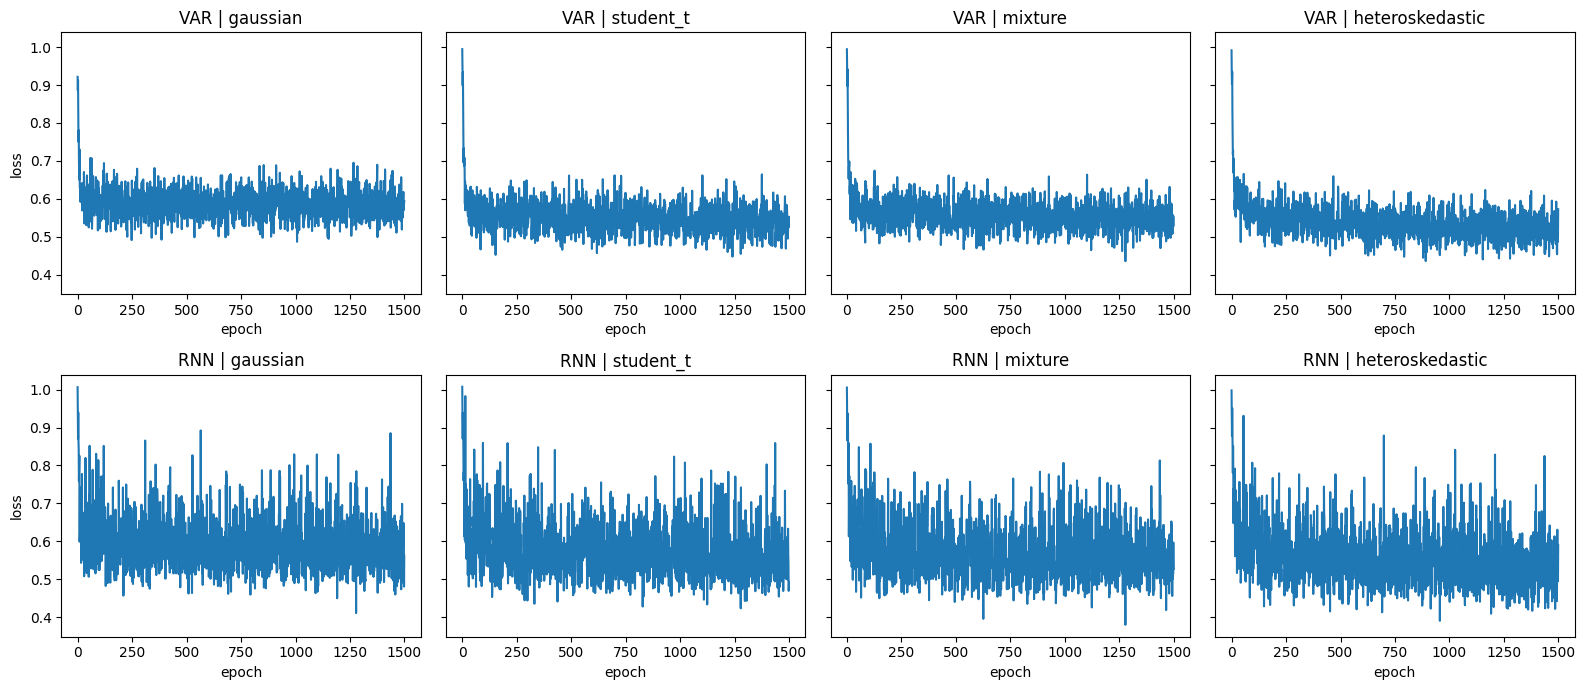

In [4]:
from src.plots.diffusion import (
    plot_diffusion_training_losses,
)

plot_diffusion_training_losses(
    diffusion_models=diffusion_models,
    forecast_models=forecast_models,
    dgp_names=dgp_names,
)

save_current_figure(
    dirs["figures"]
    / "diffusion_training_losses.png"
)

print(
    "Saved: diffusion_training_losses.png"
)

In [5]:
from src.api.innovations import diffusion_diagnostics_table
diffusion_diag_df = diffusion_diagnostics_table(
    residual_store=residual_store,
    diffusion_samples=diffusion_samples,
    forecast_models=forecast_models,
    dgp_names=dgp_names,
)

save_table(
    diffusion_diag_df,
    dirs["tables"] / "diffusion_diagnostics_by_series.csv",
)

diffusion_diag_df

,forecast_model,dgp,series,source,mean,std,skewness,kurtosis,excess_kurtosis,jb_pvalue
0,VAR,gaussian,1,empirical_residuals,-1.930823e-17,1.018841,-0.213540,3.365426,0.365426,1.584815e-01
1,VAR,gaussian,1,diffusion,-6.240058e-02,1.059084,-0.139267,3.088856,0.088856,1.899612e-08
2,VAR,gaussian,2,empirical_residuals,-1.708035e-17,0.979803,0.245287,3.304344,0.304344,1.394637e-01
3,VAR,gaussian,2,diffusion,6.578509e-02,0.932284,0.262728,3.283993,0.283993,5.848587e-33
4,VAR,gaussian,3,empirical_residuals,9.654113e-18,1.032848,0.041653,2.989496,-0.010504,9.526328e-01
5,VAR,gaussian,3,diffusion,6.516946e-02,1.037924,0.059803,2.761080,-0.238920,3.315271e-07
6,VAR,student_t,1,empirical_residuals,1.930823e-17,1.395511,0.329639,7.835382,4.835382,1.531829e-62
7,VAR,student_t,1,diffusion,1.343234e-02,1.436294,-0.128522,6.515877,3.515877,0.000000e+00
8,VAR,student_t,2,empirical_residuals,1.299592e-17,1.410934,0.295128,7.625325,4.625325,3.913417e-57
9,VAR,student_t,2,diffusion,1.813459e-01,1.389267,0.130102,6.034209,3.034209,0.000000e+00


In [6]:
from src.api.innovations import diffusion_diagnostics_summary

summary_df = diffusion_diagnostics_summary(
    diffusion_diag_df,
)

save_table(
    summary_df,
    dirs["tables"] / "diffusion_diagnostics_summary.csv",
)

summary_df

,forecast_model,dgp,source,mean,std,skewness,kurtosis,excess_kurtosis
0,RNN,gaussian,diffusion,-7.940000e-02,0.993465,-0.087577,3.030658,0.030658
1,RNN,gaussian,empirical_residuals,6.269799e-02,0.965703,0.003433,3.322708,0.322708
2,RNN,heteroskedastic,diffusion,-7.800020e-02,1.893243,-0.183816,7.123442,4.123442
3,RNN,heteroskedastic,empirical_residuals,1.853658e-02,1.852005,-0.314054,5.757487,2.757487
4,RNN,mixture,diffusion,4.046552e-02,1.358714,0.361359,8.028112,5.028112
5,RNN,mixture,empirical_residuals,7.534613e-03,1.406355,-0.020831,6.467531,3.467531
6,RNN,student_t,diffusion,-4.858257e-02,1.231040,-0.286397,6.895200,3.895200
7,RNN,student_t,empirical_residuals,-3.363383e-02,1.288047,-0.406328,6.559198,3.559198
8,VAR,gaussian,diffusion,2.285132e-02,1.009764,0.061088,3.044643,0.044643
9,VAR,gaussian,empirical_residuals,-8.911489e-18,1.010497,0.024466,3.219755,0.219755


Saved: diffusion_histogram_grid_4x4.png


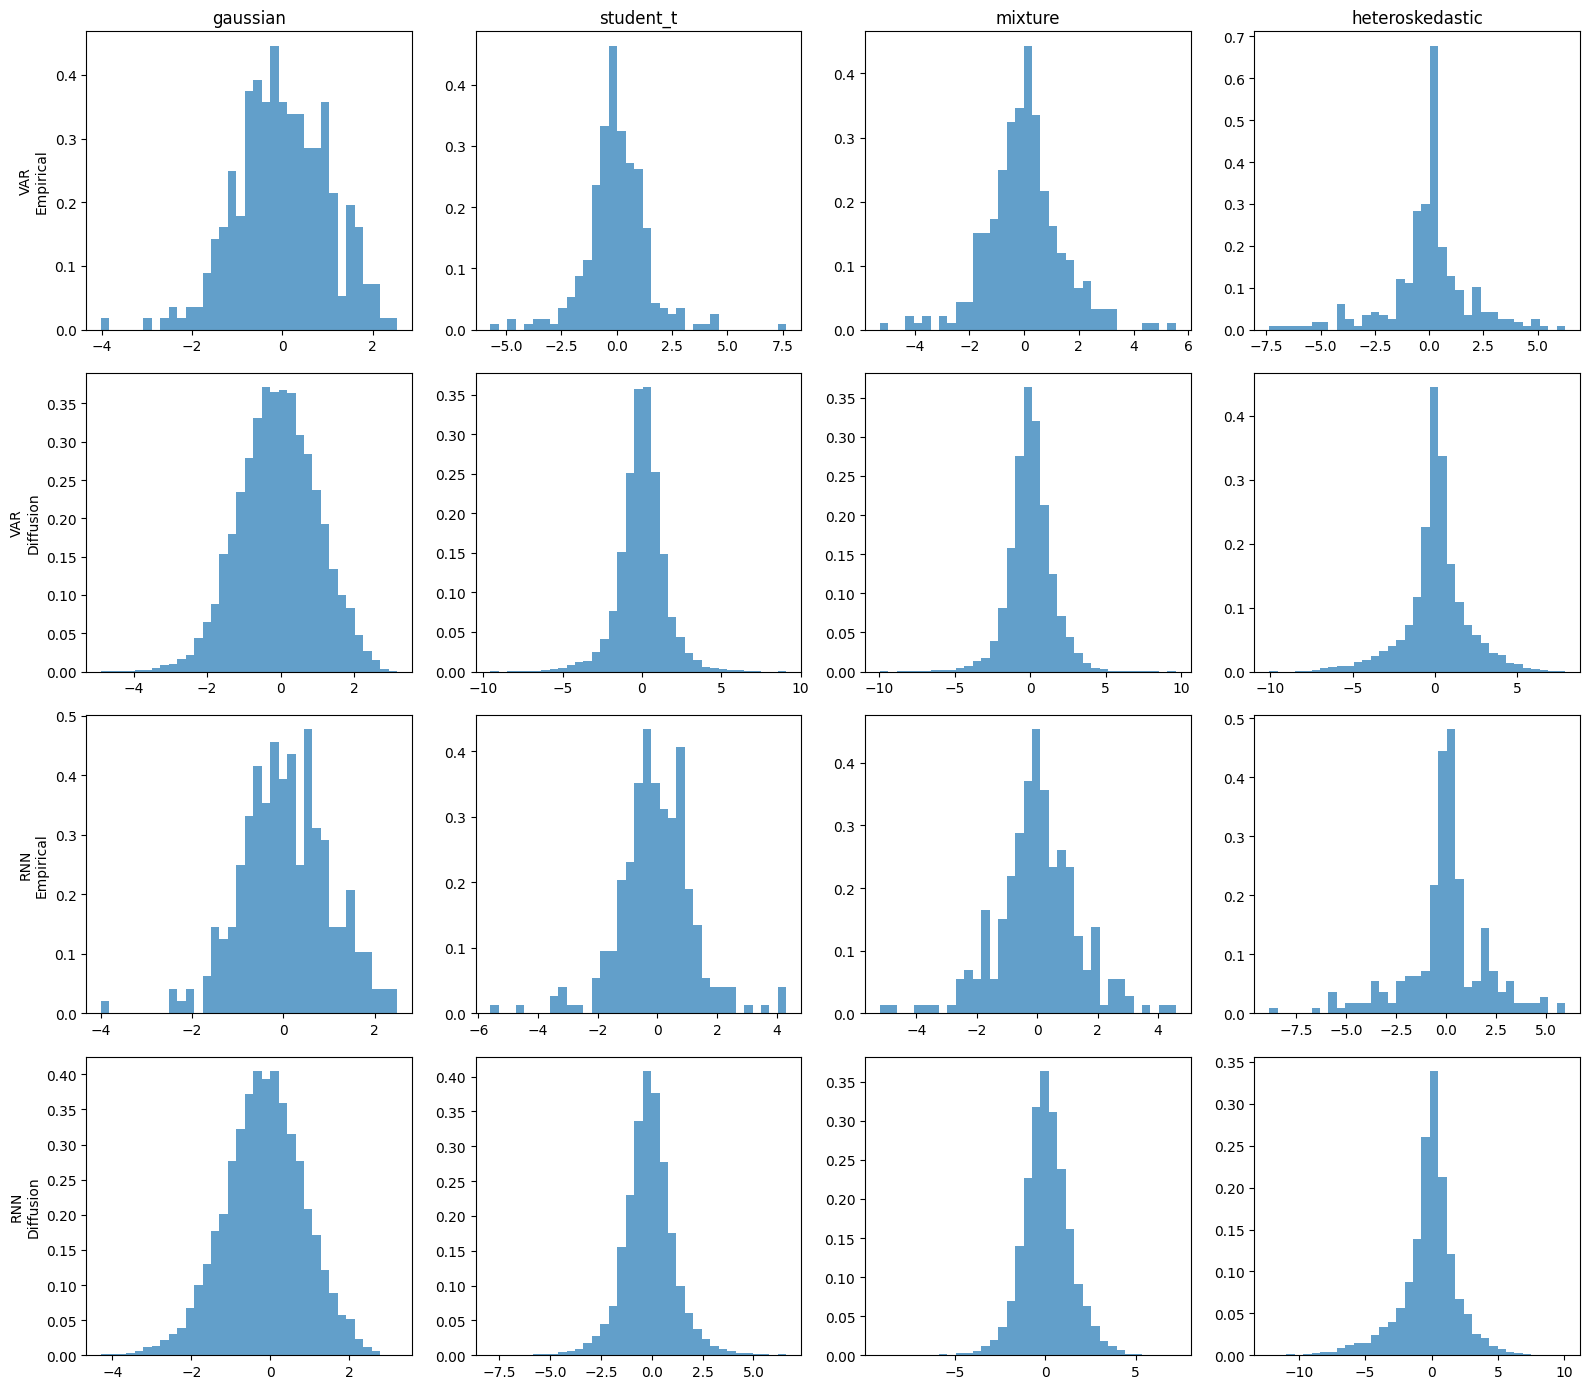

In [7]:
from src.plots.diffusion import plot_diffusion_histogram_grid

plot_diffusion_histogram_grid(
    residual_store=residual_store,
    diffusion_samples=diffusion_samples,
    dgp_names=dgp_names,
    variable=0,
)

save_current_figure(
    dirs["figures"] / "diffusion_histogram_grid_4x4.png"
)

print("Saved: diffusion_histogram_grid_4x4.png")

Saved: diffusion_qq_grid_4x4.png


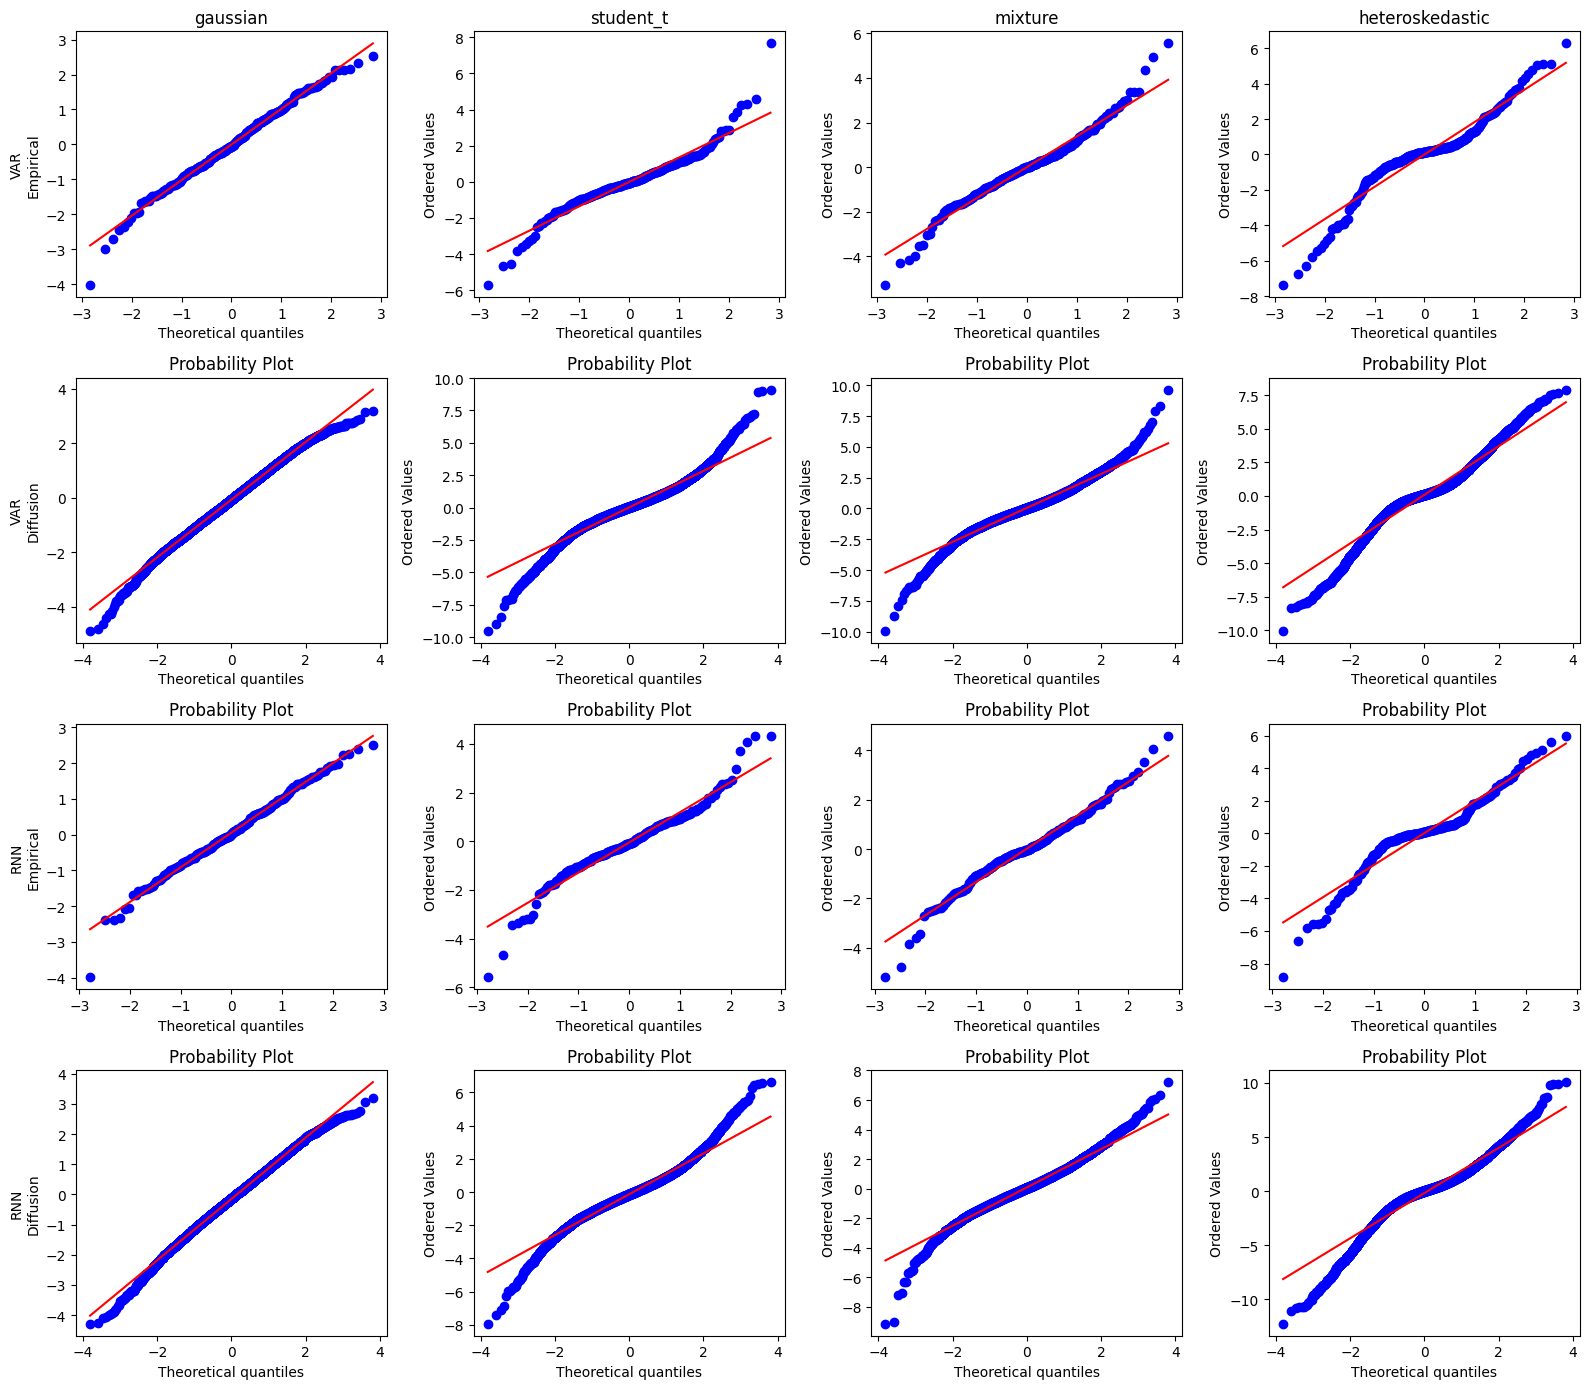

In [8]:
from src.plots.diffusion import plot_diffusion_qq_grid

plot_diffusion_qq_grid(
    residual_store=residual_store,
    diffusion_samples=diffusion_samples,
    dgp_names=dgp_names,
    variable=0,
)

save_current_figure(
    dirs["figures"]
    / "diffusion_qq_grid_4x4.png"
)

print(
    "Saved: diffusion_qq_grid_4x4.png"
)

In [9]:
from src.api.innovations import diffusion_quantile_recovery_table

quantiles = [
    0.01,
    0.05,
    0.50,
    0.95,
    0.99,
]

quantile_df = diffusion_quantile_recovery_table(
    residual_store=residual_store,
    diffusion_samples=diffusion_samples,
    forecast_models=forecast_models,
    dgp_names=dgp_names,
    quantiles=quantiles,
)

save_table(
    quantile_df,
    dirs["tables"] / "diffusion_quantile_recovery.csv",
)

quantile_df

,forecast_model,dgp,series,quantile,empirical,diffusion,absolute_error
0,VAR,gaussian,1,0.01,-2.457322,-2.659209,0.201887
1,VAR,gaussian,1,0.05,-1.530039,-1.786613,0.256573
2,VAR,gaussian,1,0.50,-0.055020,-0.058772,0.003751
3,VAR,gaussian,1,0.95,1.619425,1.687745,0.068320
4,VAR,gaussian,1,0.99,2.140730,2.278070,0.137340
...,...,...,...,...,...,...,...
115,RNN,heteroskedastic,3,0.01,-4.935025,-5.125178,0.190153
116,RNN,heteroskedastic,3,0.05,-3.381569,-2.799686,0.581883
117,RNN,heteroskedastic,3,0.50,0.028215,-0.050968,0.079183
118,RNN,heteroskedastic,3,0.95,3.221113,2.682541,0.538572


In [10]:
quantile_summary_df = (
    quantile_df
    .groupby(
        [
            "forecast_model",
            "dgp",
            "quantile",
        ]
    )["absolute_error"]
    .mean()
    .reset_index()
)

save_table(
    quantile_summary_df,
    dirs["tables"] / "diffusion_quantile_recovery_summary.csv",
)

quantile_summary_df

,forecast_model,dgp,quantile,absolute_error
0,RNN,gaussian,0.01,0.238048
1,RNN,gaussian,0.05,0.272402
2,RNN,gaussian,0.50,0.086237
3,RNN,gaussian,0.95,0.151550
4,RNN,gaussian,0.99,0.113614
5,RNN,heteroskedastic,0.01,0.745295
6,RNN,heteroskedastic,0.05,0.505690
7,RNN,heteroskedastic,0.50,0.075997
8,RNN,heteroskedastic,0.95,0.263919
9,RNN,heteroskedastic,0.99,0.196824


In [11]:
from src.api.innovations import diffusion_moment_error_table

moment_error_df = diffusion_moment_error_table(
    residual_store=residual_store,
    diffusion_samples=diffusion_samples,
    forecast_models=forecast_models,
    dgp_names=dgp_names,
)

save_table(
    moment_error_df,
    dirs["tables"] / "diffusion_moment_errors.csv",
)

moment_error_df

,forecast_model,dgp,mean_l2_error,cov_frobenius_error,skew_l2_error,kurtosis_l2_error
0,VAR,gaussian,0.111663,0.145517,0.077752,0.326794
1,VAR,student_t,0.185457,0.372231,0.523236,2.109045
2,VAR,mixture,0.133986,0.333949,0.367507,1.891591
3,VAR,heteroskedastic,0.160891,0.370945,0.665826,0.672842
4,RNN,gaussian,0.260915,0.126199,0.220275,0.555485
5,RNN,student_t,0.153694,0.475476,0.574032,2.404180
6,RNN,mixture,0.280952,0.351741,0.729062,3.292832
7,RNN,heteroskedastic,0.206853,0.926720,0.422804,2.711336


In [12]:
save_json(
    {
        "notebook": "05_diffusion",
        "forecast_models": forecast_models,
        "dgp_names": dgp_names,
        "diffusion_kwargs": {
            key: str(value)
            if "device" in key
            else value
            for key, value in diffusion_kwargs.items()
        },
        "models_saved": True,
        "samples_saved": True,
    },
    dirs["logs"] / "diffusion_config.json",
)

print(
    "05_diffusion completed."
)

05_diffusion completed.
